In [1]:
import pandas as pd

data = pd.read_csv("Bank dataset 2.csv")

print(data.head())
print(data.info())
print(data.describe())
print(data.isnull().sum())

   customer_id   age  annual_income  loan_amount  credit_score  \
0    309271753   NaN       22055.04    108494.96         610.0   
1    311621071  47.0       17331.80    452629.07         682.0   
2    267974712  32.0       50765.35          NaN         568.0   
3    872416260  66.0       29430.52    314325.91         600.0   
4    255253104  25.0        9079.24    353758.27         578.0   

  employment_status  debt_to_income_ratio  existing_loans  Unnamed: 8  \
0               NaN                 0.362             NaN         NaN   
1         Part-time                 0.129             2.0         NaN   
2         Full-time                 0.452             1.0         NaN   
3         Full-time                 0.659             0.0         NaN   
4         Part-time                 0.405             0.0         NaN   

   Unnamed: 9  Unnamed: 10  Unnamed: 11  
0         NaN          NaN          NaN  
1         NaN          NaN          NaN  
2         NaN          NaN          Na

In [2]:
import numpy as np

data["Loan_Status"] = np.where(
    (data["credit_score"] >= 650) &
    (data["annual_income"] >= 30000) &
    (data["debt_to_income_ratio"] <= 0.4),
    "Approved",
    "Rejected"
)

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

data.drop("customer_id", axis=1, inplace=True)

le = LabelEncoder()

data["employment_status"] = le.fit_transform(data["employment_status"])
data["Loan_Status"] = le.fit_transform(data["Loan_Status"])

X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [6]:
print(data.isnull().sum())

age                      3983
annual_income            3953
loan_amount              4094
credit_score             4009
employment_status           0
debt_to_income_ratio     3915
existing_loans           3998
Unnamed: 8              50000
Unnamed: 9              50000
Unnamed: 10             50000
Unnamed: 11             50000
Loan_Status                 0
dtype: int64


In [7]:
print(data.shape)
print(X.shape)
print(y.shape)

(50000, 12)
(50000, 11)
(50000,)


In [8]:
print(data["Loan_Status"].value_counts())

Loan_Status
1    43635
0     6365
Name: count, dtype: int64


In [9]:
data.fillna(data.mean(numeric_only=True), inplace=True)

In [10]:
print(X[:5])
print(y[:5])

[[        nan -0.67089086 -0.99648397 -0.82552062  2.242073   -0.288765
          nan         nan         nan         nan         nan]
 [ 0.05773284 -0.85481201  1.41103761  0.03665891 -0.04502534 -1.25088089
   0.50848338         nan         nan         nan         nan]
 [-0.85361207  0.44707757         nan -1.32845867 -0.80739146  0.08286775
  -0.33810556         nan         nan         nan         nan]
 [ 1.21210306 -0.38369251  0.44348504 -0.94526777 -0.80739146  0.93762306
  -1.18469451         nan         nan         nan         nan]
 [-1.27890636 -1.17616353  0.71934918 -1.20871152 -0.04502534 -0.11120713
  -1.18469451         nan         nan         nan         nan]]
0    1
1    1
2    1
3    1
4    1
Name: Loan_Status, dtype: int64


In [11]:
data["Loan_Status"] = np.where(
    (data["credit_score"] >= 650) &
    (data["annual_income"] >= 30000) &
    (data["debt_to_income_ratio"] <= 0.4),
    "Approved",
    "Rejected"
)

In [12]:
print(data["Loan_Status"].value_counts())

Loan_Status
Rejected    41595
Approved     8405
Name: count, dtype: int64


In [13]:
print(data.isnull().sum())

age                         0
annual_income               0
loan_amount                 0
credit_score                0
employment_status           0
debt_to_income_ratio        0
existing_loans              0
Unnamed: 8              50000
Unnamed: 9              50000
Unnamed: 10             50000
Unnamed: 11             50000
Loan_Status                 0
dtype: int64


In [14]:
import numpy as np

print(np.isinf(X).sum())

0


In [15]:
print(data.dtypes)

age                     float64
annual_income           float64
loan_amount             float64
credit_score            float64
employment_status         int64
debt_to_income_ratio    float64
existing_loans          float64
Unnamed: 8              float64
Unnamed: 9              float64
Unnamed: 10             float64
Unnamed: 11             float64
Loan_Status              object
dtype: object


In [16]:
print(np.isnan(X).sum())
print(np.isinf(X).sum())

223952
0


In [17]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

data.fillna(data.mean(numeric_only=True), inplace=True)

In [18]:
from sklearn.preprocessing import StandardScaler

X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40000, 11)
(10000, 11)
(40000,)
(10000,)


In [20]:
print(data.isnull().sum())
print(data.dtypes)
print(X.shape)
print(np.isnan(X).sum())
print(np.isinf(X).sum())

age                         0
annual_income               0
loan_amount                 0
credit_score                0
employment_status           0
debt_to_income_ratio        0
existing_loans              0
Unnamed: 8              50000
Unnamed: 9              50000
Unnamed: 10             50000
Unnamed: 11             50000
Loan_Status                 0
dtype: int64
age                     float64
annual_income           float64
loan_amount             float64
credit_score            float64
employment_status         int64
debt_to_income_ratio    float64
existing_loans          float64
Unnamed: 8              float64
Unnamed: 9              float64
Unnamed: 10             float64
Unnamed: 11             float64
Loan_Status              object
dtype: object
(50000, 11)
200000
0


In [21]:
data = data.loc[:, ~data.columns.str.contains("^Unnamed")]

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data["Loan_Status"] = le.fit_transform(data["Loan_Status"])

In [23]:
X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy =", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy = 0.9713
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      1714
           1       0.98      0.99      0.98      8286

    accuracy                           0.97     10000
   macro avg       0.96      0.94      0.95     10000
weighted avg       0.97      0.97      0.97     10000



In [27]:
print(data.shape)
print(data.isnull().sum())

(50000, 8)
age                     0
annual_income           0
loan_amount             0
credit_score            0
employment_status       0
debt_to_income_ratio    0
existing_loans          0
Loan_Status             0
dtype: int64


In [28]:
print(data.shape)
print(data.isnull().sum())

(50000, 8)
age                     0
annual_income           0
loan_amount             0
credit_score            0
employment_status       0
debt_to_income_ratio    0
existing_loans          0
Loan_Status             0
dtype: int64


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy =", dt_acc)

Decision Tree Accuracy = 1.0


In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy =", knn_acc)

KNN Accuracy = 0.945


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy =", rf_acc)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy = 1.0

Confusion Matrix
[[1714    0]
 [   0 8286]]


In [32]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy =", nb_acc)

Naive Bayes Accuracy = 0.9003


In [34]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('svm', svm),
        ('dt', dt),
        ('rf', rf)
    ],
    voting='hard'
)

ensemble.fit(X_train, y_train)

ensemble_pred = ensemble.predict(X_test)

ensemble_acc = accuracy_score(y_test, ensemble_pred)

print("Ensemble Accuracy =", ensemble_acc)

Ensemble Accuracy = 1.0


In [35]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "SVM",
        "Decision Tree",
        "KNN",
        "Random Forest",
        "Naive Bayes",
        "Ensemble"
    ],
    "Accuracy": [
        accuracy_score(y_test, svm_pred),
        dt_acc,
        knn_acc,
        rf_acc,
        nb_acc,
        ensemble_acc
    ]
})

print(results)

           Model  Accuracy
0            SVM    0.9713
1  Decision Tree    1.0000
2            KNN    0.9450
3  Random Forest    1.0000
4    Naive Bayes    0.9003
5       Ensemble    1.0000


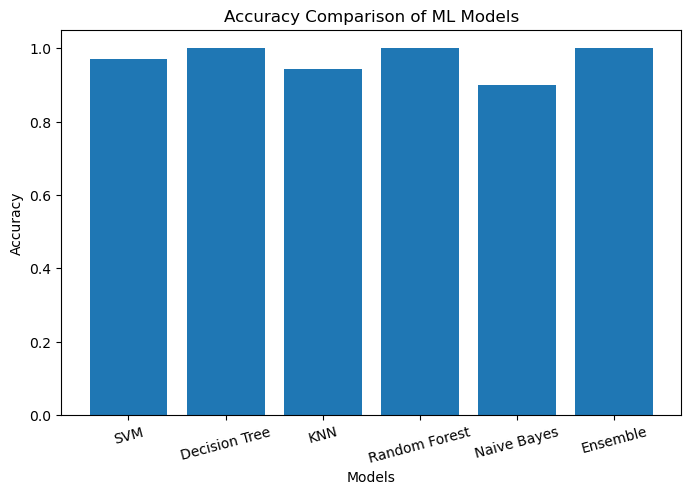

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of ML Models")

plt.xticks(rotation=15)

plt.show()